In [18]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.preprocessing import LabelEncoder

import matplotlib.pyplot as plt

In [53]:
# ============================================
# LOAD DATASETS
# ============================================

train_df = pd.read_csv("sales.csv")

holiday_df = pd.read_csv("holidays_events.csv")

print("Datasets Loaded Successfully")

Datasets Loaded Successfully


In [54]:
# ============================================
# BASIC EXPLORATION
# ============================================

print(train_df.head())

print("\nDataset Shape:")
print(train_df.shape)

print("\nColumns:")
print(train_df.columns)

   id        date  store_nbr      family  sales  onpromotion
0   0  2013-01-01          1  AUTOMOTIVE    0.0            0
1   1  2013-01-01          1   BABY CARE    0.0            0
2   2  2013-01-01          1      BEAUTY    0.0            0
3   3  2013-01-01          1   BEVERAGES    0.0            0
4   4  2013-01-01          1       BOOKS    0.0            0

Dataset Shape:
(3000888, 6)

Columns:
Index(['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion'], dtype='object')


In [55]:
# ============================================
# DATA CLEANING
# ============================================

# Convert dates
train_df['date'] = pd.to_datetime(
    train_df['date']
)

holiday_df['date'] = pd.to_datetime(
    holiday_df['date']
)

# Remove duplicates
train_df.drop_duplicates(inplace=True)

# Handle missing values
train_df.dropna(inplace=True)

print("\nCleaned Dataset Shape:")
print(train_df.shape)


Cleaned Dataset Shape:
(3000888, 6)


In [56]:
# ============================================
# FEATURE ENGINEERING
# ============================================

train_df['year'] = train_df['date'].dt.year
train_df['month'] = train_df['date'].dt.month
train_df['day'] = train_df['date'].dt.day
train_df['weekday'] = train_df['date'].dt.weekday

print(train_df.head())

   id       date  store_nbr      family  sales  onpromotion  year  month  day  \
0   0 2013-01-01          1  AUTOMOTIVE    0.0            0  2013      1    1   
1   1 2013-01-01          1   BABY CARE    0.0            0  2013      1    1   
2   2 2013-01-01          1      BEAUTY    0.0            0  2013      1    1   
3   3 2013-01-01          1   BEVERAGES    0.0            0  2013      1    1   
4   4 2013-01-01          1       BOOKS    0.0            0  2013      1    1   

   weekday  
0        1  
1        1  
2        1  
3        1  
4        1  


In [57]:
# ============================================
# HOLIDAY FEATURE
# ============================================

holiday_dates = holiday_df['date'].unique()

train_df['is_holiday'] = (
    train_df['date']
    .isin(holiday_dates)
    .astype(int)
)

print(train_df[['date',
                'is_holiday']].head())

        date  is_holiday
0 2013-01-01           1
1 2013-01-01           1
2 2013-01-01           1
3 2013-01-01           1
4 2013-01-01           1


In [58]:
# ============================================
# FEATURES & TARGET
# ============================================

X = train_df[
    [
        'year',
        'month',
        'day',
        'weekday',
        'onpromotion',
        'is_holiday'
    ]
]

y = train_df['sales']

In [59]:
# ============================================
# TRAIN TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42
)

In [60]:
# ============================================
# LINEAR REGRESSION MODEL
# ============================================

model = LinearRegression()

model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [61]:
# ============================================
# PREDICTIONS
# ============================================

predictions = model.predict(X_test)

print(predictions[:10])

[2613.30390452  201.94604156  409.28722069  195.11371932  257.31804512
  194.28861387  292.21420626  254.1810802   206.16432659  210.40083895]


In [62]:
# ============================================
# MODEL EVALUATION
# ============================================

mae = mean_absolute_error(
    y_test,
    predictions
)

mse = mean_squared_error(
    y_test,
    predictions
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    predictions
)

print("Linear Regression Performance")
print("--------------------------------")

print("MAE :", mae)

print("MSE :", mse)

print("RMSE:", rmse)

print("R2 Score:", r2)

print(f"Accuracy : {r2*100:.2f}%")

Linear Regression Performance
--------------------------------
MAE : 434.61588156066443
MSE : 1013677.6939273325
RMSE: 1006.8156206214386
R2 Score: 0.18436753114656124
Accuracy : 18.44%


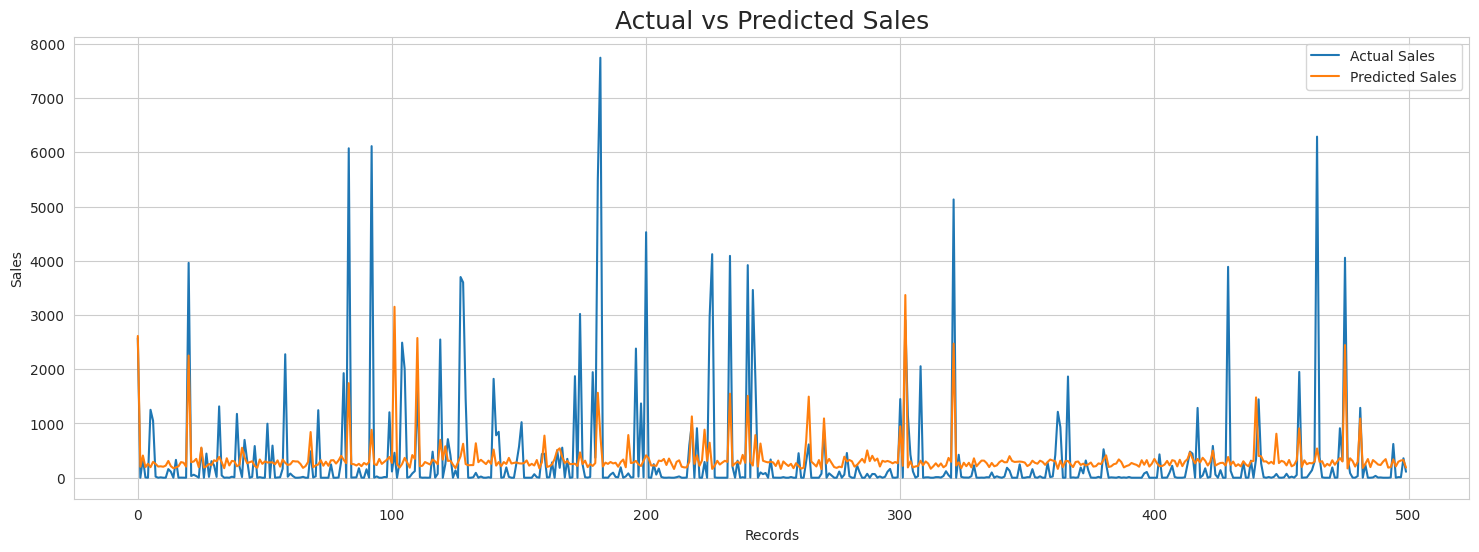

In [63]:
# ============================================
# VISUALIZATION
# ============================================

plt.figure(figsize=(18,6))

plt.plot(
    y_test.values[:500],
    label='Actual Sales'
)

plt.plot(
    predictions[:500],
    label='Predicted Sales'
)

plt.title(
    "Actual vs Predicted Sales",
    fontsize=18
)

plt.xlabel("Records")

plt.ylabel("Sales")

plt.legend()

plt.show()

In [64]:
# ============================================
# FEATURE COEFFICIENTS
# ============================================

importance = pd.DataFrame({

    'Feature': X.columns,

    'Coefficient': model.coef_
})

print(importance)

       Feature  Coefficient
0         year    -2.569943
1        month     2.644472
2          day    -1.573974
3      weekday    20.759618
4  onpromotion    38.511999
5   is_holiday     9.124224


In [66]:
# ============================================
# FUTURE PREDICTION
# ============================================

future_data = pd.DataFrame({

    'year': [2018],

    'month': [1],

    'day': [15],

    'weekday': [0],

    'onpromotion': [20],

    'is_holiday': [0]
})

future_sales = model.predict(future_data)

print("\nPredicted Future Sales:")
print(future_sales)


Predicted Future Sales:
[942.7949822]
